# Experiment 6 — Class Imbalance and Minority-Class Robustness

This notebook investigates how different machine learning models respond to class imbalance conditions.

The purpose of the experiment is to examine whether preprocessing and feature engineering can compensate for skewed class distributions and whether different inductive biases exhibit different levels of robustness when minority-class representation becomes increasingly limited.

The experiment compares:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

under controlled class imbalance conditions.

Personally, I find class imbalance particularly important because it represents one of the most common and practically relevant challenges in applied machine learning. In many real-world classification problems, the most important observations are often also the rarest ones. This creates an interesting tension between overall predictive accuracy and meaningful minority-class detection.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, experiment execution, visualization, and result saving.

In [2]:
from src.data.load_data import (
    load_adult_dataset
)

from src.experiments.class_imbalance import (
    run_class_imbalance_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Class Imbalance Configurations

The experiment evaluates multiple class imbalance conditions in order to investigate robustness under increasingly skewed class distributions.

Two imbalance levels are examined:
- Moderate imbalance
- Severe imbalance

This setup allows the analysis to investigate whether preprocessing effectiveness changes as minority-class representation becomes increasingly limited.

In [4]:
import pandas as pd

imbalance_configs = {
    "Moderate Imbalance": 0.5,
    "Severe Imbalance": 0.1
}

all_results = []

for config_name, minority_fraction in imbalance_configs.items():
    
    print(f"\nRunning configuration: {config_name}")
    
    temp_results = run_class_imbalance_experiment(
        X,
        y,
        minority_fraction=minority_fraction
    )
    
    temp_results["imbalance_level"] = config_name
    
    all_results.append(temp_results)

results_df = pd.concat(
    all_results,
    ignore_index=True
)

results_df


Running configuration: Moderate Imbalance

=== Raw Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...



=== Cleaned Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


...


=== Engineered Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc,imbalance_level
0,Raw,Logistic Regression,0.843605,0.343582,0.628117,Moderate Imbalance
1,Raw,Decision Tree,0.866628,0.515829,0.721671,Moderate Imbalance
2,Raw,Naive Bayes,0.861860,0.365385,0.821316,Moderate Imbalance
3,Raw,MLP,0.878140,0.257790,0.637407,Moderate Imbalance
4,Cleaned,Logistic Regression,0.801279,0.537983,0.900890,Moderate Imbalance
5,Cleaned,Decision Tree,0.866744,0.516047,0.721738,Moderate Imbalance
6,Cleaned,Naive Bayes,0.445116,0.314565,0.729709,Moderate Imbalance
7,Cleaned,MLP,0.880233,0.515977,0.873051,Moderate Imbalance
8,Engineered,Logistic Regression,0.792907,0.525699,0.896401,Moderate Imbalance
9,Engineered,Decision Tree,0.863023,0.503373,0.714538,Moderate Imbalance


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [5]:
save_metrics(
    results_df,
    "class_imbalance_results.csv"
)

Metrics saved to: ../results/metrics/class_imbalance_results.csv


## Class Imbalance Visualization

The following figure compares model performance across preprocessing levels under class imbalance conditions.

Plot saved to: ../results/plots/class_imbalance_f1_comparison.png


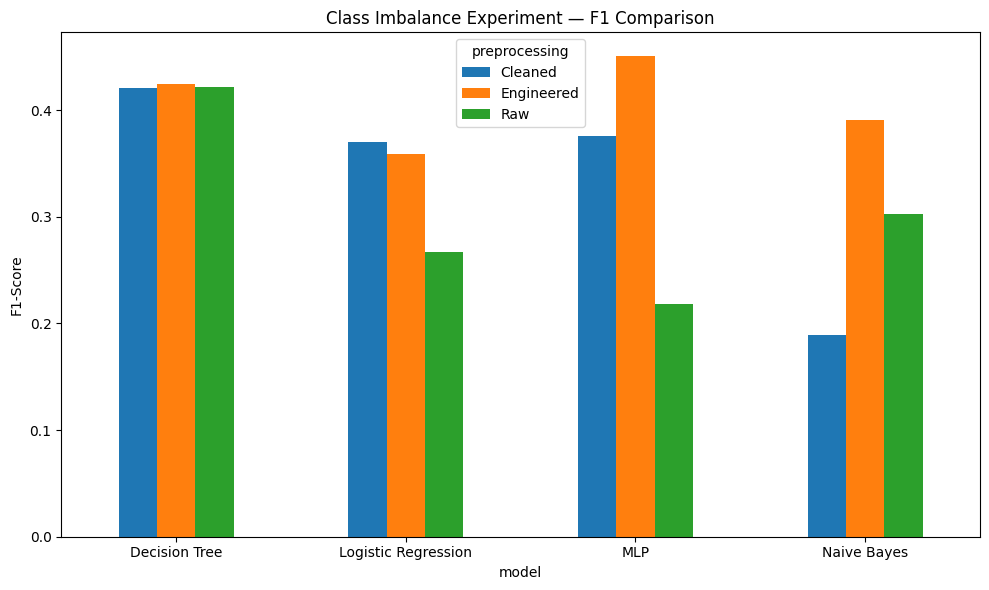

In [6]:
plot_f1_comparison(
    results_df,
    title="Class Imbalance Experiment — F1 Comparison",
    filename="class_imbalance_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [7]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="class_imbalance_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/class_imbalance_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.420524
1,Decision Tree,Engineered,0.424414
2,Decision Tree,Raw,0.421095
3,Logistic Regression,Cleaned,0.370470
4,Logistic Regression,Engineered,0.358787
5,Logistic Regression,Raw,0.266853
6,MLP,Cleaned,0.375176
7,MLP,Engineered,0.450292
8,MLP,Raw,0.217705
9,Naive Bayes,Cleaned,0.189152


## Interpretation of Class Imbalance Results

The class imbalance experiment reveals substantial differences in how models respond to skewed class distributions and limited minority-class representation.

One of the clearest findings is that raw preprocessing produces severe performance degradation for several models, particularly for minority-class prediction measured through F1-score. In contrast, cleaned and engineered preprocessing substantially improve robustness under imbalance conditions.

Logistic Regression demonstrates particularly strong sensitivity to preprocessing quality under class imbalance conditions. Under raw preprocessing, minority-class prediction deteriorates substantially, while cleaned preprocessing restores much of the lost predictive performance. This suggests that stable and well-structured feature representations remain especially important for linear decision boundaries when informative minority examples become scarce.

The Multi-Layer Perceptron (MLP) demonstrates an especially interesting pattern. Despite its greater representational flexibility, raw preprocessing produces severe degradation under strong imbalance conditions. Engineered preprocessing substantially improves predictive performance, suggesting that representation quality remains highly important even for more flexible neural architectures.

Naive Bayes again demonstrates notable improvement under engineered preprocessing conditions. One possible interpretation is that feature refinement and selection reduce unstable feature dependencies and improve the model’s ability to identify informative minority-class structure despite highly skewed distributions.

Decision Trees remain comparatively stable across preprocessing conditions, although their overall predictive performance remains slightly below the strongest-performing models. This relative stability may indicate some robustness to imbalance-related representation distortions.

Personally, I found it particularly interesting how strongly preprocessing improvements influenced minority-class robustness. In several cases, representation refinement appeared to compensate for a substantial portion of the degradation introduced through class imbalance itself.

Overall, the results increasingly support the broader motivation of the project: preprocessing quality and inductive bias alignment may play a central role in determining predictive robustness under difficult real-world conditions such as highly skewed class distributions.